In [1]:
import sympy as sm
import sympy.physics.mechanics as me

me.init_vprinting(use_latex='mathjax')

In [2]:
# Symbols
q1, q2, q3, q4 = me.dynamicsymbols('q1 q2 q3 q4')
u1, u2, u3, u4 = me.dynamicsymbols('u1 u2 u3 u4')
l1, l2, l3, l4 = sm.symbols('l1 l2 l3 l4')
m1, m2, m3, m4 = sm.symbols('m1 m2 m3 m4')
I1, I2, I3, I4 = sm.symbols('I1 I2 I3 I4')
kYoke, k1, k2, k3 = sm.symbols('kYoke k1 k2 k3')
k = sm.symbols('k')

In [3]:
# Inertial reference frame and origin
N = me.ReferenceFrame('N')
O = me.Point(N)
O.set_vel(N, 0)

In [4]:
# Rigidbodies reference frames
Ref1 = N.orientnew('Ref1', 'Axis', [q1, N.z])
P1star = O.locatenew('P1star', sm.Rational(1,2) * l1 * Ref1.x)
P1 = O.locatenew('P1', l1 * Ref1.x)

Ref2 = Ref1.orientnew('Ref2', 'Axis', [sm.pi - q2, Ref1.z])
P2star = P1.locatenew('P2star', sm.Rational(1,2) * l2 * Ref2.x)
P2 = P1.locatenew('P2', l2 * Ref2.x)

Ref3 = Ref2.orientnew('Ref3', 'Axis', [q3 - sm.pi, Ref2.z])
P3star = P2.locatenew('P3star', sm.Rational(1,2) * l3 * Ref3.x)
P3 = P2.locatenew('P3', l3 * Ref3.x)

Ref4 = Ref3.orientnew('Ref4', 'Axis', [sm.pi - q4, Ref3.z])
P4star = P3.locatenew('P4star', sm.Rational(1,2) * l4 * Ref4.x)
P4 = P3.locatenew('P4', l4 * Ref4.x)


In [5]:
# Reference frames angular velocities

Ref1.set_ang_vel(N, u1*Ref1.z)
Ref2.set_ang_vel(Ref1, -u2*Ref2.z)
Ref3.set_ang_vel(Ref2, u3*Ref3.z)
Ref4.set_ang_vel(Ref3, -u4*Ref4.z)

Ref1.ang_vel_in(N), Ref2.ang_vel_in(N), Ref3.ang_vel_in(N), Ref4.ang_vel_in(N)


(u₁ ref1_z, -u₂ ref2_z + u₁ ref1_z, u₃ ref3_z + -u₂ ref2_z + u₁ ref1_z, -u₄ ref4_z + u₃ ref3_z + -u₂ ref2_z + u₁ ref1_z)

In [6]:
# Mass center velocities
P1star.set_vel(N, P1star.pos_from(O).dt(N))
P2star.set_vel(N, P2star.pos_from(O).dt(N))
P3star.set_vel(N, P3star.pos_from(O).dt(N))
P4star.set_vel(N, P4star.pos_from(O).dt(N))

P1star.vel(N), P2star.vel(N), P3star.vel(N), P4star.vel(N)

⎛l₁⋅u₁         l₂⋅(u₁ - u₂)                        l₃⋅(u₁ - u₂ + u₃)                                              l₄⋅( ↪
⎜───── ref1_y, ──────────── ref2_y + l₁⋅u₁ ref1_y, ───────────────── ref3_y + l₂⋅(u₁ - u₂) ref2_y + l₁⋅u₁ ref1_y, ──── ↪
⎝  2                2                                      2                                                           ↪

↪ u₁ - u₂ + u₃ - u₄)                                                                       ⎞
↪ ────────────────── ref4_y + l₃⋅(u₁ - u₂ + u₃) ref3_y + l₂⋅(u₁ - u₂) ref2_y + l₁⋅u₁ ref1_y⎟
↪       2                                                                                  ⎠

In [7]:
# Inertial angular accelerations
Ref1.ang_acc_in(N), Ref2.ang_acc_in(N), Ref3.ang_acc_in(N), Ref4.ang_acc_in(N)

(u₁̇ ref1_z, -u₂̇ ref2_z + u₁̇ ref1_z, u₃̇ ref3_z + -u₂̇ ref2_z + u₁̇ ref1_z, -u₄̇ ref4_z + u₃̇ ref3_z + -u₂̇ ref2_z + u₁̇ ref1_z)

In [8]:
# Intertial linear accelerations
P1star.acc(N), P2star.acc(N), P3star.acc(N), P4star.acc(N)

⎛      2                                      2                                                                        ↪
⎜-l₁⋅u₁            l₁⋅u₁̇         -l₂⋅(u₁ - u₂)            l₂⋅(u₁̇ - u₂̇)                2                        -l₃⋅(u₁ ↪
⎜──────── ref1_x + ───── ref1_y, ─────────────── ref2_x + ──────────── ref2_y + -l₁⋅u₁  ref1_x + l₁⋅u₁̇ ref1_y, ─────── ↪
⎝   2                2                  2                      2                                                       ↪

↪            2                                                                                                         ↪
↪  - u₂ + u₃)            l₃⋅(u₁̇ - u₂̇ + u₃̇)                       2                                      2              ↪
↪ ───────────── ref3_x + ───────────────── ref3_y + -l₂⋅(u₁ - u₂)  ref2_x + l₂⋅(u₁̇ - u₂̇) ref2_y + -l₁⋅u₁  ref1_x + l₁⋅ ↪
↪   2                            2                                                                                     ↪

↪                    

In [9]:
# Closed loop torques, pretorques and frictions
T1 = k*(2*q1-q2)
T2 = k*(q2-q3)
T3 = k*(q3-q4)

pTYoke, pT1, pT2, pT3 = sm.symbols('pTYoke pT1 pT2 pT3')
TfYoke, Tf1, Tf2, Tf3 = sm.symbols('TfYoke Tf1 Tf2 Tf3')

In [10]:
# Resultant forces and torques
R_P1star = 0*N.x + 0*N.y + 0*N.z
R_P2star = 0*N.x + 0*N.y + 0*N.z
R_P3star = 0*N.x + 0*N.y + 0*N.z
R_P4star = 0*N.x + 0*N.y + 0*N.z

T_Ref1 = pTYoke*Ref1.z + pT1*Ref1.z + kYoke*(sm.Rational(1,2)*sm.pi - q1)*Ref1.z + k1*(sm.pi - q2)*Ref1.z - T2*Ref1.z - TfYoke*sm.sign(u1)*Ref1.z - Tf1*sm.sign(u2)*Ref1.z
T_Ref2 = -pT1*Ref2.z - pT2*Ref2.z - k1*(sm.pi - q2)*Ref2.z - k2*(sm.pi - q3)*Ref2.z + T3*Ref2.z - T1*Ref2.z + Tf1*sm.sign(u2)*Ref2.z + Tf2*sm.sign(u3)*Ref2.z
T_Ref3 = pT2*Ref3.z + pT3*Ref3.z + k2*(sm.pi - q3)*Ref3.z + k3*(sm.pi - q4)*Ref4.z + T2*Ref3.z - Tf2*sm.sign(u3)*Ref3.z - Tf3*sm.sign(u4)*Ref3.z
T_Ref4 = -pT3*Ref4.z - k3*(sm.pi - q4)*Ref4.z - T3*Ref4.z + Tf3*sm.sign(u4)*Ref4.z



In [11]:
# Rods inertias
inertia1 = I1*me.outer(Ref1.z,Ref1.z)
inertia2 = I2*me.outer(Ref2.z,Ref2.z)
inertia3 = I3*me.outer(Ref3.z,Ref3.z)
inertia4 = I4*me.outer(Ref4.z,Ref4.z)

inertia1, inertia2, inertia3, inertia4

AttributeError: 'Fake' object has no attribute 'height'

In [12]:
# Partial linear velocities
v_P1star_1 = P1star.vel(N).diff(u1, N)
v_P1star_2 = P1star.vel(N).diff(u2, N)
v_P1star_3 = P1star.vel(N).diff(u3, N)
v_P1star_4 = P1star.vel(N).diff(u4, N)

v_P2star_1 = P2star.vel(N).diff(u1, N)
v_P2star_2 = P2star.vel(N).diff(u2, N)
v_P2star_3 = P2star.vel(N).diff(u3, N)
v_P2star_4 = P2star.vel(N).diff(u4, N)

v_P3star_1 = P3star.vel(N).diff(u1, N)
v_P3star_2 = P3star.vel(N).diff(u2, N)
v_P3star_3 = P3star.vel(N).diff(u3, N)
v_P3star_4 = P3star.vel(N).diff(u4, N)

v_P4star_1 = P4star.vel(N).diff(u1, N)
v_P4star_2 = P4star.vel(N).diff(u2, N)
v_P4star_3 = P4star.vel(N).diff(u3, N)
v_P4star_4 = P4star.vel(N).diff(u4, N)

# By means of "partial_velocity()" function

lin_par_vels = me.partial_velocity([P1star.vel(N), P2star.vel(N), P3star.vel(N), P4star.vel(N)], [u1, u2, u3, u4], N)

v_P3star_1, lin_par_vels[2][0]

⎛l₃                                 l₃                               ⎞
⎜── ref3_y + l₂ ref2_y + l₁ ref1_y, ── ref3_y + l₂ ref2_y + l₁ ref1_y⎟
⎝2                                  2                                ⎠

In [13]:
# Partial angular velocities
w_Ref1_1 = Ref1.ang_vel_in(N).diff(u1, N)
w_Ref1_2 = Ref1.ang_vel_in(N).diff(u2, N)
w_Ref1_3 = Ref1.ang_vel_in(N).diff(u3, N)
w_Ref1_4 = Ref1.ang_vel_in(N).diff(u4, N)

w_Ref2_1 = Ref2.ang_vel_in(N).diff(u1, N)
w_Ref2_2 = Ref2.ang_vel_in(N).diff(u2, N)
w_Ref2_3 = Ref2.ang_vel_in(N).diff(u3, N)
w_Ref2_4 = Ref2.ang_vel_in(N).diff(u4, N)

w_Ref3_1 = Ref3.ang_vel_in(N).diff(u1, N)
w_Ref3_2 = Ref3.ang_vel_in(N).diff(u2, N)
w_Ref3_3 = Ref3.ang_vel_in(N).diff(u3, N)
w_Ref3_4 = Ref3.ang_vel_in(N).diff(u4, N)

w_Ref4_1 = Ref4.ang_vel_in(N).diff(u1, N)
w_Ref4_2 = Ref4.ang_vel_in(N).diff(u2, N)
w_Ref4_3 = Ref4.ang_vel_in(N).diff(u3, N)
w_Ref4_4 = Ref4.ang_vel_in(N).diff(u4, N)

# By means of "partial_velocity()" function

ang_par_vels = me.partial_velocity([Ref1.ang_vel_in(N), Ref2.ang_vel_in(N), Ref3.ang_vel_in(N), Ref4.ang_vel_in(N)], [u1, u2, u3, u4], N)

w_Ref1_1, ang_par_vels[0][0]

(ref1_z, ref1_z)

In [14]:
# Generalized active forces
F1 = v_P1star_1.dot(R_P1star) + v_P2star_1.dot(R_P2star) + v_P3star_1.dot(R_P3star) + v_P4star_1.dot(R_P4star) + w_Ref1_1.dot(T_Ref1) + w_Ref2_1.dot(T_Ref2) + w_Ref3_1.dot(T_Ref3) + w_Ref4_1.dot(T_Ref4)
F2 = v_P1star_2.dot(R_P1star) + v_P2star_2.dot(R_P2star) + v_P3star_2.dot(R_P3star) + v_P4star_2.dot(R_P4star) + w_Ref1_2.dot(T_Ref1) + w_Ref2_2.dot(T_Ref2) + w_Ref3_2.dot(T_Ref3) + w_Ref4_2.dot(T_Ref4)
F3 = v_P1star_3.dot(R_P1star) + v_P2star_3.dot(R_P2star) + v_P3star_3.dot(R_P3star) + v_P4star_3.dot(R_P4star) + w_Ref1_3.dot(T_Ref1) + w_Ref2_3.dot(T_Ref2) + w_Ref3_3.dot(T_Ref3) + w_Ref4_3.dot(T_Ref4)
F4 = v_P1star_4.dot(R_P1star) + v_P2star_4.dot(R_P2star) + v_P3star_4.dot(R_P3star) + v_P4star_4.dot(R_P4star) + w_Ref1_4.dot(T_Ref1) + w_Ref2_4.dot(T_Ref2) + w_Ref3_4.dot(T_Ref3) + w_Ref4_4.dot(T_Ref4)

# Trigonometric simplification
F1 = sm.trigsimp(F1)
F2 = sm.trigsimp(F2)
F3 = sm.trigsimp(F3)
F4 = sm.trigsimp(F4)


In [15]:
# Generalized active force vector
Fr = sm.Matrix([F1, F2, F3, F4])
Fr

⎡                                           ⎛      π⎞           ⎤
⎢  -TfYoke⋅sign(u₁) - k⋅(2⋅q₁ - q₂) + kYoke⋅⎜-q₁ + ─⎟ + pTYoke  ⎥
⎢                                           ⎝      2⎠           ⎥
⎢                                                               ⎥
⎢-Tf₁⋅sign(u₂) + k⋅(2⋅q₁ - q₂) - k⋅(q₂ - q₃) + k₁⋅(π - q₂) + pT₁⎥
⎢                                                               ⎥
⎢ -Tf₂⋅sign(u₃) + k⋅(q₂ - q₃) - k⋅(q₃ - q₄) + k₂⋅(π - q₃) + pT₂ ⎥
⎢                                                               ⎥
⎣        -Tf₃⋅sign(u₄) + k⋅(q₃ - q₄) + k₃⋅(π - q₄) + pT₃        ⎦

In [16]:
# Generalized inertia forces
Rs1 = -m1*P1star.acc(N)
Rs2 = -m2*P2star.acc(N)
Rs3 = -m3*P3star.acc(N)
Rs4 = -m4*P4star.acc(N)

Ts1 = -(Ref1.ang_acc_in(N).dot(inertia1) + me.cross(Ref1.ang_vel_in(N), inertia1).dot(Ref1.ang_vel_in(N)))
Ts2 = -(Ref2.ang_acc_in(N).dot(inertia2) + me.cross(Ref2.ang_vel_in(N), inertia2).dot(Ref2.ang_vel_in(N)))
Ts3 = -(Ref3.ang_acc_in(N).dot(inertia3) + me.cross(Ref3.ang_vel_in(N), inertia3).dot(Ref3.ang_vel_in(N)))
Ts4 = -(Ref4.ang_acc_in(N).dot(inertia4) + me.cross(Ref4.ang_vel_in(N), inertia4).dot(Ref4.ang_vel_in(N)))

F1s = v_P1star_1.dot(Rs1) + v_P2star_1.dot(Rs2) + v_P3star_1.dot(Rs3) + v_P4star_1.dot(Rs4) + w_Ref1_1.dot(Ts1) + w_Ref2_1.dot(Ts2) + w_Ref3_1.dot(Ts3) + w_Ref4_1.dot(Ts4)
F2s = v_P1star_2.dot(Rs1) + v_P2star_2.dot(Rs2) + v_P3star_2.dot(Rs3) + v_P4star_2.dot(Rs4) + w_Ref1_2.dot(Ts1) + w_Ref2_2.dot(Ts2) + w_Ref3_2.dot(Ts3) + w_Ref4_2.dot(Ts4)
F3s = v_P1star_3.dot(Rs1) + v_P2star_3.dot(Rs2) + v_P3star_3.dot(Rs3) + v_P4star_3.dot(Rs4) + w_Ref1_3.dot(Ts1) + w_Ref2_3.dot(Ts2) + w_Ref3_3.dot(Ts3) + w_Ref4_3.dot(Ts4)
F4s = v_P1star_4.dot(Rs1) + v_P2star_4.dot(Rs2) + v_P3star_4.dot(Rs3) + v_P4star_4.dot(Rs4) + w_Ref1_4.dot(Ts1) + w_Ref2_4.dot(Ts2) + w_Ref3_4.dot(Ts3) + w_Ref4_4.dot(Ts4)

# Trigonometric simplification
F1s = sm.trigsimp(F1s)
F2s = sm.trigsimp(F2s)
F3s = sm.trigsimp(F3s)
F4s = sm.trigsimp(F4s)

Ts1, Ts2, Ts3, Ts4

(-I₁⋅u₁̇ ref1_z, -I₂⋅(u₁̇ - u₂̇) ref2_z, -I₃⋅(u₁̇ - u₂̇ + u₃̇) ref3_z, -I₄⋅(u₁̇ - u₂̇ + u₃̇ - u₄̇) ref4_z)

In [17]:
# Generalized inertial force vector
Frs = sm.Matrix([F1s, F2s, F3s, F4s])
Frs

⎡                                                                       2                                              ↪
⎢                                                                     l₁ ⋅m₁⋅u₁̇     2           2           2          ↪
⎢-I₁⋅u₁̇ - I₂⋅(u₁̇ - u₂̇) - I₃⋅(u₁̇ - u₂̇ + u₃̇) - I₄⋅(u₁̇ - u₂̇ + u₃̇ - u₄̇) - ───────── - l₁ ⋅m₂⋅u₁̇ - l₁ ⋅m₃⋅u₁̇ - l₁ ⋅m₄⋅u₁̇ +  ↪
⎢                                                                         4                                            ↪
⎢                                                                                                                      ↪
⎢                                                                                                                      ↪
⎢                                                                                                                      ↪
⎢                                                                                                                      ↪
⎢                 

In [18]:
# Kane's equations
Fr + Frs

⎡                                                                                                                      ↪
⎢                                                                                                             ⎛      π ↪
⎢-I₁⋅u₁̇ - I₂⋅(u₁̇ - u₂̇) - I₃⋅(u₁̇ - u₂̇ + u₃̇) - I₄⋅(u₁̇ - u₂̇ + u₃̇ - u₄̇) - TfYoke⋅sign(u₁) - k⋅(2⋅q₁ - q₂) + kYoke⋅⎜-q₁ + ─ ↪
⎢                                                                                                             ⎝      2 ↪
⎢                                                                                                                      ↪
⎢                                                                                                                      ↪
⎢                                                                                                                      ↪
⎢                                                                                                                      ↪
⎢                     

In [19]:
me.find_dynamicsymbols(Fr)

{q₁, q₂, q₃, q₄, u₁, u₂, u₃, u₄}

In [20]:
me.find_dynamicsymbols(Frs)

{q₂, q₃, q₄, u₁, u₂, u₃, u₄, u₁̇, u₂̇, u₃̇, u₄̇}

In [21]:
u = sm.Matrix([u1, u2, u3, u4])
q = sm.Matrix([q1, q2, q3, q4])
t = me.dynamicsymbols._t
ud = u.diff(t)
qd = q.diff(t)

ud, qd

⎛⎡u₁̇⎤  ⎡q₁̇⎤⎞
⎜⎢  ⎥  ⎢  ⎥⎟
⎜⎢u₂̇⎥  ⎢q₂̇⎥⎟
⎜⎢  ⎥, ⎢  ⎥⎟
⎜⎢u₃̇⎥  ⎢q₃̇⎥⎟
⎜⎢  ⎥  ⎢  ⎥⎟
⎝⎣u₄̇⎦  ⎣q₄̇⎦⎠

In [22]:
Mk = -sm.eye(4)
Mk

⎡-1  0   0   0 ⎤
⎢              ⎥
⎢0   -1  0   0 ⎥
⎢              ⎥
⎢0   0   -1  0 ⎥
⎢              ⎥
⎣0   0   0   -1⎦

In [23]:
gk = u

In [24]:
Md = Frs.jacobian(ud)
Md

⎡                       2                                                                                              ↪
⎢                     l₁ ⋅m₁     2        2        2                                                                   ↪
⎢-I₁ - I₂ - I₃ - I₄ - ────── - l₁ ⋅m₂ - l₁ ⋅m₃ - l₁ ⋅m₄ + l₁⋅l₂⋅m₂⋅cos(q₂) + 2⋅l₁⋅l₂⋅m₃⋅cos(q₂) + 2⋅l₁⋅l₂⋅m₄⋅cos(q₂) - ↪
⎢                       4                                                                                              ↪
⎢                                                                                                                      ↪
⎢                                                                                                                      ↪
⎢                                       l₁⋅l₂⋅m₂⋅cos(q₂)                                         l₁⋅l₃⋅m₃⋅cos(q₂ - q₃) ↪
⎢                        I₂ + I₃ + I₄ - ──────────────── - l₁⋅l₂⋅m₃⋅cos(q₂) - l₁⋅l₂⋅m₄⋅cos(q₂) + ───────────────────── ↪
⎢                               

In [25]:
ud_zerod = {udr: 0 for udr in ud}
ud_zerod

{u₁̇: 0, u₂̇: 0, u₃̇: 0, u₄̇: 0}

In [26]:
gd = Frs.xreplace(ud_zerod) + Fr
gd

⎡                                                                       2                      2                       ↪
⎢                                         ⎛      π⎞   l₁⋅l₂⋅m₂⋅(u₁ - u₂) ⋅sin(q₂)   l₁⋅l₂⋅m₂⋅u₁ ⋅sin(q₂)               ↪
⎢-TfYoke⋅sign(u₁) - k⋅(2⋅q₁ - q₂) + kYoke⋅⎜-q₁ + ─⎟ + ─────────────────────────── - ──────────────────── + l₁⋅l₂⋅m₃⋅(u ↪
⎢                                         ⎝      2⎠                2                         2                         ↪
⎢                                                                                                                      ↪
⎢                                                                                                                      ↪
⎢                                                                                                                      ↪
⎢                                                                                                            -Tf₁⋅sign ↪
⎢                               

In [27]:
me.find_dynamicsymbols(Md)

{q₂, q₃, q₄}

In [28]:
me.find_dynamicsymbols(gd)

{q₁, q₂, q₃, q₄, u₁, u₂, u₃, u₄}

In [29]:
Mk.free_symbols | gk.free_symbols | Md.free_symbols | gd.free_symbols

{I₁, I₂, I₃, I₄, Tf₁, Tf₂, Tf₃, TfYoke, k, k₁, k₂, k₃, kYoke, l₁, l₂, l₃, l₄, m₁, m₂, m₃, m₄, pT₁, pT₂, pT₃, pTYoke, t}

In [30]:
p = sm.Matrix([I1, I2, I3, I4, TfYoke, Tf1, Tf2, Tf3, k, kYoke, k1, k2, k3, l1, l2, l3, l4, m1, m2, m3, m4, pTYoke, pT1, pT2, pT3])
p

⎡  I₁  ⎤
⎢      ⎥
⎢  I₂  ⎥
⎢      ⎥
⎢  I₃  ⎥
⎢      ⎥
⎢  I₄  ⎥
⎢      ⎥
⎢TfYoke⎥
⎢      ⎥
⎢ Tf₁  ⎥
⎢      ⎥
⎢ Tf₂  ⎥
⎢      ⎥
⎢ Tf₃  ⎥
⎢      ⎥
⎢  k   ⎥
⎢      ⎥
⎢kYoke ⎥
⎢      ⎥
⎢  k₁  ⎥
⎢      ⎥
⎢  k₂  ⎥
⎢      ⎥
⎢  k₃  ⎥
⎢      ⎥
⎢  l₁  ⎥
⎢      ⎥
⎢  l₂  ⎥
⎢      ⎥
⎢  l₃  ⎥
⎢      ⎥
⎢  l₄  ⎥
⎢      ⎥
⎢  m₁  ⎥
⎢      ⎥
⎢  m₂  ⎥
⎢      ⎥
⎢  m₃  ⎥
⎢      ⎥
⎢  m₄  ⎥
⎢      ⎥
⎢pTYoke⎥
⎢      ⎥
⎢ pT₁  ⎥
⎢      ⎥
⎢ pT₂  ⎥
⎢      ⎥
⎣ pT₃  ⎦

In [31]:
eval_eom = sm.lambdify((q, u, p), [Mk, gk, Md, gd])

In [32]:
import numpy as np

In [33]:
# q values just for try
q_vals = np.array([
    np.deg2rad(10.0),  # q1, rad
    np.deg2rad(10.0),  # q2, rad
    np.deg2rad(10.0),  # q3, rad
    np.deg2rad(10.0),  # q4, rad
])
q_vals, type(q_vals), q_vals.shape

(array([0.17453293, 0.17453293, 0.17453293, 0.17453293]), numpy.ndarray, (4,))

In [34]:
# u values just for try
u_vals = np.array([
    0.1,  # u1, rad/s
    0.1,  # u2, rad/s
    0.1,  # u3, rad/s
    0.1,  # u4, rad/s
])
u_vals, type(u_vals), u_vals.shape

(array([0.1, 0.1, 0.1, 0.1]), numpy.ndarray, (4,))

In [35]:
# Parameter values

p_vals = np.array([
    0.2798, # I1, kgm^2
    4.2009, # I2, kgm^2
    3.8773, # I3, kgm^2
    2.9316, # I4, kgm^2
    0.66, # TfYoke, Nm
    0.64, # Tf1, Nm
    0.69, # Tf2, Nm
    0.70, # Tf3, Nm
    1.5152, # k, Nm/rad
    0.1273, # kYoke, Nm/rad
    0.1305, # k1, Nm/rad
    0.1305, # k2, Nm/rad
    0.1305, # k3, Nm/rad
    1.090, # l1, m
    1.965, # l2, m
    1.965, # l3, m
    1.936, # l4, m
    2.222, # m1, kg
    12.637, # m2, kg
    9.982, # m3, kg
    8.920, # m4, kg
    1.70 - 0.1273*0.5*np.pi, # pTqYoke, Nm
    0.85 - 0.1305*np.pi, # pTq1, Nm
    0.85 - 0.1305*np.pi, # pTq2, Nm
    0.85 - 0.1305*np.pi, # pTq3, Nm
]) 
p_vals, type(p_vals), p_vals.shape

(array([ 0.2798    ,  4.2009    ,  3.8773    ,  2.9316    ,  0.66      ,
         0.64      ,  0.69      ,  0.7       ,  1.5152    ,  0.1273    ,
         0.1305    ,  0.1305    ,  0.1305    ,  1.09      ,  1.965     ,
         1.965     ,  1.936     ,  2.222     , 12.637     ,  9.982     ,
         8.92      ,  1.50003763,  0.44002216,  0.44002216,  0.44002216]),
 numpy.ndarray,
 (25,))

In [36]:
# Matrix values just for try
Mk_vals, gk_vals, Md_vals, gd_vals = eval_eom(q_vals, u_vals, p_vals)
Mk_vals, gk_vals, Md_vals, gd_vals

(array([[-1,  0,  0,  0],
        [ 0, -1,  0,  0],
        [ 0,  0, -1,  0],
        [ 0,  0,  0, -1]]),
 array([[0.1],
        [0.1],
        [0.1],
        [0.1]]),
 array([[-16.41862866,  10.67862895, -10.42270582,   2.27893359],
        [ 10.67862895, -43.34990468, -10.10388355, -11.54761957],
        [-10.42270582, -10.10388355, -25.82667825,  -5.41929083],
        [  2.27893359, -11.54761957,  -5.41929083, -11.28985408]]),
 array([[0.52044904],
        [0.68455637],
        [0.09141753],
        [0.17302938]]))

In [37]:
def eval_rhs(t, y, p):
    """Return the right hand side of the explicit ordinary differential
    equations which evaluates the time derivative of the state ``y`` at time
    ``t``.

    Parameters
    ==========
    t : float
       Time in seconds.
    y : array_like, shape(8,)
       State at time t: [q1, q2, q3, q4, u1, u2, u3, u4]
    p : array_like, shape(23,)
       Constant parameters: [I1, I2, I3, I4, Tf1, Tf2, Tf3, Tf4, g, k, kYoke, l1, l2, l3, l4, m1, m2, m3, m4, pTq1, pTq2, pTq3, pTq4]

    Returns
    =======
    yd : ndarray, shape(8,)
        Derivative of the state with respect to time at time ``t``.

    """

    # unpack the q and u vectors from x
    q = y[:4]
    u = y[4:]

    # evaluate the equations of motion matrices with the values of q, u, p
    Mk, gk, Md, gd = eval_eom(q, u, p)

    # solve for q' and u'
    qd = np.linalg.solve(-Mk, np.squeeze(gk))
    ud = np.linalg.solve(-Md, np.squeeze(gd))

    # pack dq/dt and du/dt into a new state time derivative vector dx/dt
    yd = np.empty_like(y)
    yd[:4] = qd
    yd[4:] = ud

    return yd

In [38]:
from scipy.integrate import solve_ivp

# Initial generalized coordinates and generalized speeds
q0 = [0,0,0,0] 
u0 = [0,0,0,0]

# Initial time
t0 = 0.0 # s

# Final time
tf = 20.0 # s

# Time span
t_span = [t0, tf] 

# Initial conditions.
y0 = np.array(q0 + u0)

# Latch-up joint stiffness
kJoint_lu = [3000, 1500, 1500, 1500]  

# Latch-up events
def event_q1(t,y,p):
    return y[0] - np.pi/2 # First joint latch-up
event_q1.terminal = True # Ends the integration
event_q1.direction = 1 # Detect values from negative to positive

def event_q2(t,y,p):
    return y[1] - np.pi # Second joint latch-up
event_q2.terminal = True 
event_q2.direction = 1 

def event_q3(t,y,p):
    return y[2] - np.pi # Third joint latch-up
event_q3.terminal = True 
event_q3.direction = 1 

def event_q4(t,y,p):
    return y[3] - np.pi # Fourth joint latch-up
event_q4.terminal = True 
event_q4.direction = 1 

# List of index states for active events
active_events_index = [0, 1, 2, 3]  # Corresponds to the indexes of states with events

# Function to handle the change of stiffness
def update_stiffness(state, kJoint_lu):
    p_vals[9+state] = kJoint_lu[state]

# Simulation
total_time = []
total_states = []

initial_t = t_span[0]
while initial_t < t_span[1]:
    # Select active events
    events_act = []
    for idx in active_events_index:
        if idx == 0:
            events_act.append(event_q1)
        elif idx == 1:
            events_act.append(event_q2)
        elif idx == 2:
            events_act.append(event_q3)
        elif idx == 3:
            events_act.append(event_q4)
    
    print(events_act)
    # Integrate the system with active events
    sol = solve_ivp(eval_rhs, [initial_t, t_span[1]], y0, args=(p_vals,), events=events_act, dense_output=True)
    
    # Save partial results
    total_time.append(sol.t)
    total_states.append(sol.y)
    
    print(sol.t_events)
    print(sol.y_events)
    # Check if any event occurred
    for i, t_event in enumerate(sol.t_events):
        if t_event.size > 0:  # If the event occurred
            t_event = t_event[0]
            y_event = sol.y_events[i][0]

            # Identify the index of the state corresponding to the event
            idx_state = active_events_index[i]

            # Update stiffness depending on event
            update_stiffness(idx_state, kJoint_lu)
            
            # Remove the status index from the active event list
            active_events_index.remove(idx_state)

            # Update the intial conditions
            y0 = sol.sol(t_event) + 1e-6
            initial_t = t_event  # Avoid re-integrating at the same point

            break
    else:
        # If there were no events, finish the simulation
        break

# Combine results into single arrays
ts = np.concatenate(total_time)
ys = np.hstack(total_states)



[<function event_q1 at 0x000001DCC2B745E0>, <function event_q2 at 0x000001DCCF4CB880>, <function event_q3 at 0x000001DCCF86AC20>, <function event_q4 at 0x000001DCCF86ACB0>]
[array([16.7831651]), array([], dtype=float64), array([], dtype=float64), array([], dtype=float64)]
[array([[1.57079633, 2.61161994, 2.39572533, 2.28352817, 0.26574197,
        0.59197415, 0.62366049, 0.54680627]]), array([], dtype=float64), array([], dtype=float64), array([], dtype=float64)]
[<function event_q2 at 0x000001DCCF4CB880>, <function event_q3 at 0x000001DCCF86AC20>, <function event_q4 at 0x000001DCCF86ACB0>]
[array([], dtype=float64), array([], dtype=float64), array([17.65667231])]
[array([], dtype=float64), array([], dtype=float64), array([[ 1.58053186,  2.87446263,  3.10215636,  3.14159265, -0.2366075 ,
        -0.03677909,  0.81794584,  1.19743582]])]
[<function event_q2 at 0x000001DCCF4CB880>, <function event_q3 at 0x000001DCCF86AC20>]
[array([], dtype=float64), array([17.8406798])]
[array([], dtype=

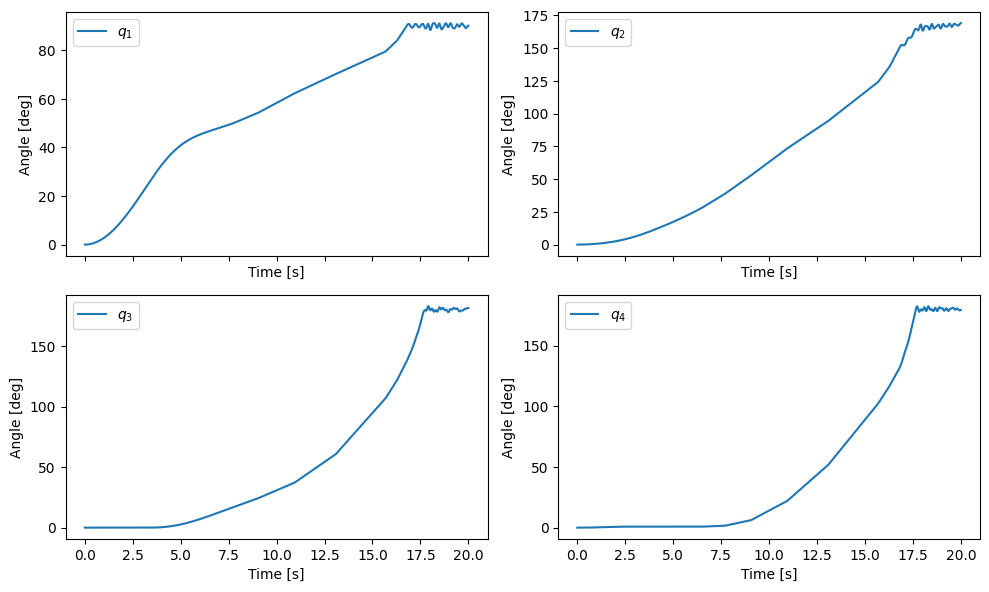

In [39]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2,2, sharex=True)
fig.set_size_inches((10.0, 6.0))

axes[0,0].plot(ts, np.rad2deg(ys[0,:]))
axes[0,1].plot(ts, np.rad2deg(ys[1,:]))
axes[1,0].plot(ts, np.rad2deg(ys[2,:]))
axes[1,1].plot(ts, np.rad2deg(ys[3,:]))

axes[0,0].legend([me.vlatex(q[0], mode='inline')])
axes[0,1].legend([me.vlatex(q[1], mode='inline')])
axes[1,0].legend([me.vlatex(q[2], mode='inline')])
axes[1,1].legend([me.vlatex(q[3], mode='inline')])

axes[0,0].set_ylabel('Angle [deg]')
axes[0,1].set_ylabel('Angle [deg]')
axes[1,0].set_ylabel('Angle [deg]')
axes[1,1].set_ylabel('Angle [deg]')

axes[0,0].set_xlabel('Time [s]')
axes[0,1].set_xlabel('Time [s]')
axes[1,0].set_xlabel('Time [s]')
axes[1,1].set_xlabel('Time [s]')

fig.tight_layout()